#  Fraud Detection Pipeline
## Phát hiện giao dịch gian lận trong thương mại điện tử

### Mô tả bài toán
- **Dataset**: 300,000 giao dịch thương mại điện tử
- **Mục tiêu**: Phân loại giao dịch gian lận (`Is Fraudulent = 1`)
- **Thách thức**: Dataset mất cân bằng nghiêm trọng (~5% fraud)

### Metric đánh giá chính
| Metric | Lý do chọn |
|--------|-----------|
| **F2-score** | Metric chính — penalize việc bỏ sót fraud nặng hơn false alarm |
| **PR-AUC** | Đánh giá tổng thể khả năng phân biệt fraud trên mọi threshold |
| **Recall** | Tỷ lệ fraud thực sự bị phát hiện |


### Pipeline tổng quan
```
Load Data → EDA → Feature Engineering → Train/Test Split
→ Group Statistics → Pattern Features
→ Spark MLlib: LR + RF + GBT → Chọn Best Model (F2)
→ Threshold Tuning (F2) → Final Evaluation
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, f1_score, fbeta_score,
    precision_score, recall_score
)

from pyspark.sql import SparkSession
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler as SparkScaler,
    StringIndexer, OneHotEncoder as SparkOHE
)
from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    RandomForestClassifier as SparkRF,
    GBTClassifier
)
from pyspark.sql.functions import col, when

TARGET_COL = "Is Fraudulent"
DATE_COL   = "Transaction Date"

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("default")

print(" Imports loaded")

 Imports loaded


## Load & Khám phá dữ liệu (EDA)

### Các vấn đề phát hiện từ EDA
1. **Mixed datetime format** → dùng `format='mixed'`
2. **High-cardinality features** (`IP Address`, `Customer Location`) → leakage nghiêm trọng (train corr=0.99, test corr=0.006) → **DROP hoàn toàn**
3. **Customer Age** có giá trị < 18 → clean bằng median của train


 Spark 4.1.1 | Master: local[*]
 Spark read from HDFS: hdfs://localhost:9000/final/fraud_300k_raw_temporal.csv
 Spark DataFrame: 300,000 rows × 16 columns
root
 |-- Transaction ID: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Transaction Amount: string (nullable = true)
 |-- Transaction Date: string (nullable = true)
 |-- Payment Method: string (nullable = true)
 |-- Product Category: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- Customer Age: string (nullable = true)
 |-- Customer Location: string (nullable = true)
 |-- Device Used: string (nullable = true)
 |-- IP Address: string (nullable = true)
 |-- Shipping Address: string (nullable = true)
 |-- Billing Address: string (nullable = true)
 |-- Is Fraudulent: string (nullable = true)
 |-- Account Age Days: string (nullable = true)
 |-- Transaction Hour: string (nullable = true)


 Check label values from Spark:
+-------------+
|Is Fraudulent|
+-------------+
|1            |
|0     

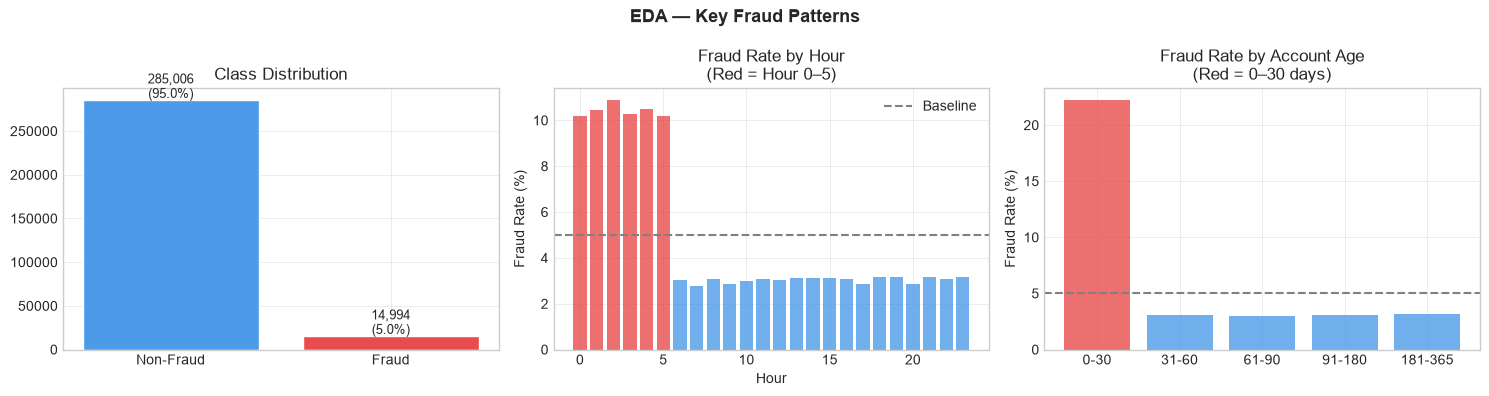

In [2]:
HDFS_PATH = "hdfs://localhost:9000/final/fraud_300k_raw_temporal.csv"

spark = SparkSession.builder \
    .appName("FraudDetection_HDFS_MLlib") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true") \
    .config("spark.python.worker.faulthandler.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f" Spark {spark.version} | Master: {spark.sparkContext.master}")

df_spark_raw = (
    spark.read
         .option("header", "true")
         .option("inferSchema", "false")
         .option("multiLine", "true")
         .option("mode", "PERMISSIVE")
         .option("quote", '"')
         .option("escape", '"')
         .csv(HDFS_PATH)
)

df_spark_raw = df_spark_raw.toDF(*[c.strip() for c in df_spark_raw.columns])

spark_rows = df_spark_raw.count()
print(f" Spark read from HDFS: {HDFS_PATH}")
print(f" Spark DataFrame: {spark_rows:,} rows × {len(df_spark_raw.columns)} columns")
df_spark_raw.printSchema()

if spark_rows == 0:
    raise ValueError("Spark đọc được 0 dòng từ HDFS. Kiểm tra lại HDFS_PATH hoặc file CSV trên HDFS.")

print("\n Check label values from Spark:")
df_spark_raw.select(TARGET_COL).distinct().show(30, truncate=False)

df = df_spark_raw.toPandas()
df.columns = [c.strip() for c in df.columns]

required_cols = [DATE_COL, TARGET_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Thiếu cột bắt buộc: {missing_cols}. Các cột hiện có: {df.columns.tolist()}")

date_raw = df[DATE_COL].copy()
try:
    df[DATE_COL] = pd.to_datetime(date_raw, format="mixed", dayfirst=False, errors="coerce")
except Exception:
    df[DATE_COL] = pd.to_datetime(date_raw, dayfirst=False, errors="coerce")

if df[DATE_COL].notna().sum() == 0:
    try:
        date_alt = pd.to_datetime(date_raw, format="mixed", dayfirst=True, errors="coerce")
    except Exception:
        date_alt = pd.to_datetime(date_raw, dayfirst=True, errors="coerce")
    if date_alt.notna().sum() > df[DATE_COL].notna().sum():
        df[DATE_COL] = date_alt

print("\n Giá trị gốc của label trước xử lý:")
print(df[TARGET_COL].value_counts(dropna=False).head(20))

label_raw = df[TARGET_COL]
if label_raw.dtype == "bool":
    df[TARGET_COL] = label_raw.astype(int)
else:
    label_str = (
        label_raw.astype(str)
                 .str.strip()
                 .str.replace('"', '', regex=False)
                 .str.replace("'", "", regex=False)
                 .str.lower()
    )
    label_map = {
        "1": 1, "1.0": 1, "true": 1, "t": 1, "yes": 1, "y": 1,
        "fraud": 1, "fraudulent": 1, "is fraud": 1, "is fraudulent": 1,
        "0": 0, "0.0": 0, "false": 0, "f": 0, "no": 0, "n": 0,
        "non-fraud": 0, "non fraud": 0, "not fraud": 0,
        "not fraudulent": 0, "legitimate": 0, "normal": 0
    }
    mapped_label = label_str.map(label_map)
    numeric_label = pd.to_numeric(label_raw, errors="coerce")
    df[TARGET_COL] = mapped_label.fillna(numeric_label)

numeric_cols = [
    "Transaction Amount", "Quantity", "Customer Age",
    "Account Age Days", "Transaction Hour"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

before_rows = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)
df = df[df[TARGET_COL].isin([0, 1])].copy()
after_rows = len(df)

print("\n Giá trị label sau xử lý:")
print(df[TARGET_COL].value_counts(dropna=False).sort_index())
print(f"\n Rows before label cleaning: {before_rows:,}")
print(f" Rows after label cleaning : {after_rows:,}")

if after_rows == 0:
    raise ValueError("Sau khi xử lý label, df còn 0 dòng. Kiểm tra lại TARGET_COL hoặc cách đọc CSV từ HDFS.")
if df[TARGET_COL].nunique() < 2:
    raise ValueError(f"Cột {TARGET_COL} chỉ còn một lớp: {df[TARGET_COL].unique()}. Stratified split cần đủ 0 và 1.")

fraud_rate = df[TARGET_COL].mean()
imbalance_text = f"imbalance ratio 1:{int((1 - fraud_rate) / fraud_rate)}" if fraud_rate > 0 else "imbalance ratio không tính được"

if df[DATE_COL].notna().any():
    date_text = f"{df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}"
else:
    date_text = "Không parse được ngày hợp lệ"

print(f"\n Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Range  : {date_text}")
print(f"⚖  Fraud  : {fraud_rate*100:.2f}%  ({imbalance_text})")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA — Key Fraud Patterns", fontsize=13, fontweight="bold")

# 1. Class imbalance
counts = df[TARGET_COL].value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(["Non-Fraud", "Fraud"], counts.values,
            color=["#4C9BE8", "#E84C4C"], edgecolor="white")
axes[0].set_title("Class Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.01,
                 f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=9)

hour_fraud = df.groupby("Transaction Hour")[TARGET_COL].mean() * 100
axes[1].bar(hour_fraud.index, hour_fraud.values,
            color=["#E84C4C" if h <= 5 else "#4C9BE8" for h in hour_fraud.index],
            alpha=0.8)
axes[1].set_title("Fraud Rate by Hour\n(Red = Hour 0–5)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].axhline(fraud_rate * 100, color="gray", linestyle="--", label="Baseline")
axes[1].legend()

df_tmp = df.copy()
df_tmp["age_bucket"] = pd.cut(
    df_tmp["Account Age Days"],
    bins=[0, 30, 60, 90, 180, 365, 999],
    labels=["0-30", "31-60", "61-90", "91-180", "181-365", "365+"],
    include_lowest=True
)
age_fraud = df_tmp.groupby("age_bucket")[TARGET_COL].mean() * 100
axes[2].bar(age_fraud.index, age_fraud.values,
            color=["#E84C4C" if i == 0 else "#4C9BE8" for i in range(len(age_fraud))],
            alpha=0.8)
axes[2].set_title("Fraud Rate by Account Age\n(Red = 0–30 days)")
axes[2].set_ylabel("Fraud Rate (%)")
axes[2].axhline(fraud_rate * 100, color="gray", linestyle="--")

plt.tight_layout()
plt.show()

##  Feature Engineering

### Nguyên tắc chống Data Leakage
- **DROP** cột định danh: `Transaction ID`, `Customer ID`, `IP Address`, `Customer Location`
- Mọi threshold (Q25, Q80, median) **fit chỉ trên train set**
- Scaler/Encoder nằm trong `ColumnTransformer` — chỉ fit trên train

### Features được tạo
| Feature | Loại |
|---------|------|
| `is_night` | Binary |
| `amount_log` | Numerical |
| `is_very_new_account` | Binary |
| `is_high_amount` | Binary |
| `new_x_night` | Interaction |
| `new_x_highamount` | Interaction |
| `new_night_highamount` | Interaction |
| `account_age_clipped` | Numerical |
| `*_fraud_rate` | Statistical |

In [3]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["Shipping Address"] = df["Shipping Address"].astype(str)
    df["Billing Address"] = df["Billing Address"].astype(str)

    df["address_mismatch"] = (
        df["Shipping Address"].str.strip() != df["Billing Address"].str.strip()
    ).astype(int)

    df["is_night"]         = (df["Transaction Hour"] <= 5).astype(int)
    df["amount_log"]       = np.log1p(df["Transaction Amount"])
    df["amount_per_qty"]   = df["Transaction Amount"] / df["Quantity"].replace(0, 1)
    df["account_age_days"] = df["Account Age Days"]
    df["customer_age"]     = df["Customer Age"].clip(lower=10)

    df["tx_hour"] = df[DATE_COL].dt.hour
    if "Transaction Hour" in df.columns:
        df["tx_hour"] = df["tx_hour"].fillna(df["Transaction Hour"])
    df["tx_hour"] = df["tx_hour"].fillna(0).astype(int)

    df["tx_dayofweek"] = df[DATE_COL].dt.dayofweek.fillna(0).astype(int)
    return df

df = feature_engineering(df)
print(" Base features created")


 Base features created


##  Train/Test Split (Stratified)

Dùng `stratify=y` để đảm bảo tỷ lệ fraud **giống nhau** trong train và test.
Mọi threshold và statistics được tính **chỉ trên train set** sau bước này để tránh data leakage.

In [4]:
if len(df) == 0:
    raise ValueError("df đang rỗng trước train_test_split. Hãy kiểm tra lại CELL 4.")
if df[TARGET_COL].nunique() < 2:
    raise ValueError(f"{TARGET_COL} cần đủ 2 lớp 0 và 1 để stratify. Hiện có: {df[TARGET_COL].value_counts().to_dict()}")

DROP_COLS = [
    "Transaction ID", "Customer ID", DATE_COL,
    "IP Address", "Customer Location",
    "Shipping Address", "Billing Address",
    "Customer Age", "Account Age Days",
    "Transaction Hour", "Transaction Amount",
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X = df.drop(columns=DROP_COLS + [TARGET_COL])
y = df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f" Split: Train={len(X_train):,} | Test={len(X_test):,}")
print(f" Fraud — Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

# Fix Customer Age (median từ train)
age_median = X_train["customer_age"][X_train["customer_age"] >= 18].median()
for df_ in [X_train, X_test]:
    df_["customer_age"] = df_["customer_age"].apply(lambda x: age_median if x < 18 else x)
print(f"\n Customer age median (train): {age_median}")

# Group Statistics (fit ONLY on train)
train_tmp   = X_train.copy()
train_tmp["__label__"] = y_train.values
global_mean = y_train.mean()

for col_name in ["Payment Method", "Product Category", "Device Used"]:
    stats = (train_tmp.groupby(col_name)["__label__"]
             .agg(["mean", "count"])
             .rename(columns={"mean": "fraud_rate", "count": "n"}))
    smoothing = 20
    stats["smoothed"] = (
        (stats["n"] * stats["fraud_rate"] + smoothing * global_mean)
        / (stats["n"] + smoothing)
    )
    feat_name  = col_name.lower().replace(" ", "_") + "_fraud_rate"
    encode_map = stats["smoothed"].to_dict()
    X_train[feat_name] = X_train[col_name].map(encode_map).fillna(global_mean)
    X_test[feat_name]  = X_test[col_name].map(encode_map).fillna(global_mean)

cat_amount_mean = train_tmp.groupby("Product Category")["amount_log"].mean().to_dict()
cat_qty_mean    = train_tmp.groupby("Product Category")["Quantity"].mean().to_dict()
for df_ in [X_train, X_test]:
    df_["amount_vs_category"] = (
        df_["amount_log"] - df_["Product Category"].map(cat_amount_mean).fillna(0)
    )
    df_["qty_vs_category"] = (
        df_["Quantity"] - df_["Product Category"].map(cat_qty_mean).fillna(0)
    )
print(" Group statistics features created")

# Pattern Features (threshold từ train)
amt_q80        = X_train["amount_log"].quantile(0.80)
age_q25_train  = X_train["account_age_days"].quantile(0.25)

for df_ in [X_train, X_test]:
    df_["is_new_account"]       = (df_["account_age_days"] <= age_q25_train).astype(int)
    df_["is_very_new_account"]  = (df_["account_age_days"] <= 30).astype(int)
    df_["account_age_clipped"]  = df_["account_age_days"].clip(upper=60)
    df_["is_high_amount"]       = (df_["amount_log"] >= amt_q80).astype(int)
    df_["new_x_night"]          = df_["is_new_account"]     * df_["is_night"]
    df_["amount_x_night"]       = df_["amount_log"]          * df_["is_night"]
    df_["amount_x_very_new"]    = df_["amount_log"]          * df_["is_very_new_account"]
    df_["mismatch_x_amount"]    = df_["address_mismatch"]    * df_["amount_log"]
    df_["new_x_highamount"]     = df_["is_very_new_account"] * df_["is_high_amount"]
    df_["new_night_highamount"] = (
        df_["is_very_new_account"] * df_["is_night"] * df_["is_high_amount"]
    )
print(" Pattern features created")

# Verify
tmp = X_train.copy()
tmp["label"] = y_train.values
print(f"\n Signal verification (train):")
print(f"   is_very_new_account=1  : {tmp[tmp['is_very_new_account']==1]['label'].mean()*100:.1f}% fraud")
print(f"   new_x_highamount=1     : {tmp[tmp['new_x_highamount']==1]['label'].mean()*100:.1f}% fraud")
print(f"   new_night_highamount=1 : {tmp[tmp['new_night_highamount']==1]['label'].mean()*100:.1f}% fraud  ← strongest signal")


 Split: Train=240,000 | Test=60,000
 Fraud — Train: 5.00% | Test: 5.00%

 Customer age median (train): 35.0
 Group statistics features created
 Pattern features created

 Signal verification (train):
   is_very_new_account=1  : 22.1% fraud
   new_x_highamount=1     : 38.2% fraud
   new_night_highamount=1 : 58.2% fraud  ← strongest signal


##  Huấn luyện & So sánh Models

### Chiến lược
Sử dụng **Apache Spark MLlib** để huấn luyện 3 model phân tán, sau đó **tự động chọn model tốt nhất** theo F2-score.

| Model |
|-------|
| Logistic Regression |
| Random Forest |
| GBT (Gradient Boosted Trees) |



In [5]:
spark = SparkSession.getActiveSession()
if spark is None:
    spark = SparkSession.builder \
        .appName("FraudDetection_HDFS_MLlib") \
        .master("local[*]") \
        .config("spark.driver.memory", "4g") \
        .config("spark.sql.shuffle.partitions", "8") \
        .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f" Spark {spark.version} | Master: {spark.sparkContext.master}")

train_pd = X_train.copy().reset_index(drop=True)
train_pd["label"] = y_train.values

test_pd = X_test.copy().reset_index(drop=True)
test_pd["label"] = y_test.values

test_pd["__row_id__"] = np.arange(len(test_pd))

for c in ["Payment Method", "Product Category", "Device Used"]:
    if c in train_pd.columns:
        train_pd[c] = train_pd[c].astype(str)
    if c in test_pd.columns:
        test_pd[c] = test_pd[c].astype(str)

train_spark = spark.createDataFrame(train_pd)
test_spark  = spark.createDataFrame(test_pd)
print(f" Spark DataFrames: train={train_spark.count():,} | test={test_spark.count():,}")

# ── Feature columns cho Spark ──
SPARK_NUM = [
    "amount_log", "account_age_clipped", "tx_hour",
    "amount_x_very_new", "amount_vs_category", "qty_vs_category",
    "payment_method_fraud_rate", "product_category_fraud_rate", "device_used_fraud_rate",
]
SPARK_BIN = [
    "is_night", "is_very_new_account", "is_high_amount",
    "new_x_night", "new_night_highamount", "new_x_highamount",
]
SPARK_CAT = ["Payment Method", "Product Category", "Device Used"]

SPARK_NUM = [c for c in SPARK_NUM if c in train_pd.columns]
SPARK_BIN = [c for c in SPARK_BIN if c in train_pd.columns]
SPARK_CAT = [c for c in SPARK_CAT if c in train_pd.columns]

neg_n = train_spark.filter(col("label") == 0).count()
pos_n = train_spark.filter(col("label") == 1).count()
if pos_n == 0:
    raise ValueError("Train set không có fraud label=1, không thể tính classWeight.")

w_pos = float(neg_n / pos_n)
train_spark_w = train_spark.withColumn(
    "classWeight",
    when(col("label") == 1, w_pos).otherwise(1.0)
)
print(f"  scale_pos_weight = {w_pos:.2f}  (áp dụng cho LR, RF, GBT)")

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in SPARK_CAT
]
encoders = [
    SparkOHE(inputCol=f"{c}_idx", outputCol=f"{c}_ohe", handleInvalid="keep")
    for c in SPARK_CAT
]
ohe_cols = [f"{c}_ohe" for c in SPARK_CAT]

assembler = VectorAssembler(
    inputCols=SPARK_NUM + SPARK_BIN + ohe_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)
scaler = SparkScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)
base_stages = indexers + encoders + [assembler, scaler]

lr_clf = SparkLR(
    featuresCol="features", labelCol="label",
    weightCol="classWeight",
    maxIter=100, regParam=0.01, elasticNetParam=0.5
)
rf_clf = SparkRF(
    featuresCol="features", labelCol="label",
    weightCol="classWeight",
    numTrees=100, maxDepth=5, seed=42
)
gbt_clf = GBTClassifier(
    featuresCol="features", labelCol="label",
    weightCol="classWeight",
    maxIter=50, maxDepth=4, stepSize=0.05, seed=42
)

print("\n Training Logistic Regression (Spark MLlib)...")
fitted_lr = SparkPipeline(stages=base_stages + [lr_clf]).fit(train_spark_w)
print("    Done")

print(" Training Random Forest (Spark MLlib)...")
fitted_rf = SparkPipeline(stages=base_stages + [rf_clf]).fit(train_spark_w)
print("    Done")

print(" Training GBT (Spark MLlib)...")
fitted_gbt = SparkPipeline(stages=base_stages + [gbt_clf]).fit(train_spark_w)
print("    Done")


 Spark 4.1.1 | Master: local[*]
 Spark DataFrames: train=240,000 | test=60,000
  scale_pos_weight = 19.01  (áp dụng cho LR, RF, GBT)

 Training Logistic Regression (Spark MLlib)...
    Done
 Training Random Forest (Spark MLlib)...
    Done
 Training GBT (Spark MLlib)...
    Done


 Evaluating all models...
    Logistic Regression: collected 60,000 predictions
    Random Forest: collected 60,000 predictions
    GBT: collected 60,000 predictions
 Feature importances extracted (30 features)
 Spark session is kept alive for later cells

 MODEL COMPARISON — sorted by F2-score (metric chính)


,PR-AUC,ROC-AUC,F2-score,Recall,Precision,Best Threshold
Model,,,,,,
GBT,0.5800,0.8459,0.5372,0.6209,0.3490,0.70
Random Forest,0.3857,0.8310,0.5173,0.6966,0.2549,0.47
Logistic Regression,0.3802,0.8214,0.4656,0.6312,0.2272,0.59


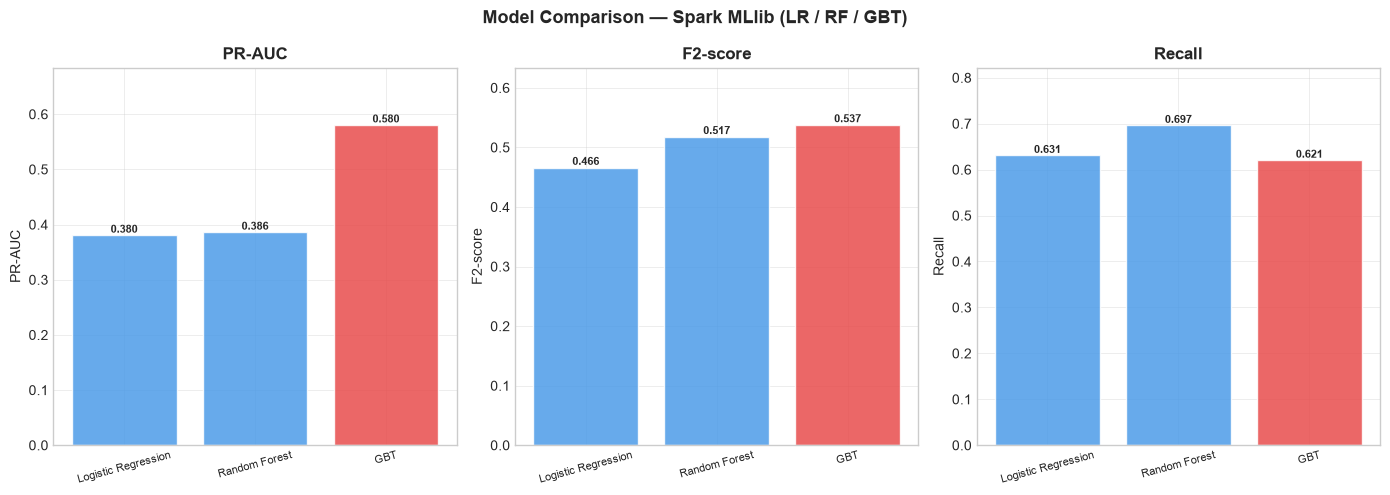


 MODEL ĐƯỢC CHỌN: GBT
   F2-score cao nhất  : 0.5372
   PR-AUC             : 0.5800
   ROC-AUC            : 0.8459
   Recall             : 0.6209
   Precision          : 0.3490
   Threshold (tuned)  : 0.70
   weightCol          : xử lý imbalance không cần SMOTE



In [6]:
from pyspark.ml.classification import (
    RandomForestClassificationModel,
    GBTClassificationModel,
    LogisticRegressionModel
)

try:
    from pyspark.ml.functions import vector_to_array
    HAS_VECTOR_TO_ARRAY = True
except Exception:
    HAS_VECTOR_TO_ARRAY = False

# ── Helper: lấy probability từ Spark pipeline ──
def get_spark_prob(fitted_pipeline, test_spark, model_name):
    preds = fitted_pipeline.transform(test_spark)

    if HAS_VECTOR_TO_ARRAY:
        prob_df = preds.select(
            col("__row_id__").cast("long").alias("__row_id__"),
            col("label").cast("int").alias("label"),
            vector_to_array(col("probability"))[1].cast("double").alias("prob")
        )
        pdf = prob_df.orderBy("__row_id__").toPandas()
    else:
        # Fallback: collect vector probability rồi lấy phần tử [1] ở pandas, KHÔNG dùng Python UDF trong Spark
        pdf = preds.select("__row_id__", "label", "probability").orderBy("__row_id__").toPandas()
        pdf["prob"] = pdf["probability"].apply(lambda v: float(v[1]) if v is not None else np.nan)

    pdf["label"] = pd.to_numeric(pdf["label"], errors="coerce")
    pdf["prob"] = pd.to_numeric(pdf["prob"], errors="coerce")
    pdf = pdf.dropna(subset=["label", "prob"])

    if len(pdf) == 0:
        raise ValueError(f"{model_name}: Không lấy được probability hợp lệ từ Spark predictions.")

    y_true = pdf["label"].astype(int).values
    y_prob = pdf["prob"].astype(float).clip(0, 1).values
    print(f"    {model_name}: collected {len(pdf):,} predictions")
    return y_true, y_prob

def get_metrics(y_true, y_prob, model_name):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)

    if len(np.unique(y_true)) < 2:
        raise ValueError(f"{model_name}: y_true chỉ có một lớp, không thể tính ROC-AUC/PR-AUC.")

    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    best_t, best_f2 = 0.5, -1
    for t in np.arange(0.10, 0.90, 0.01):
        y_pred_tmp = (y_prob >= t).astype(int)
        f2 = fbeta_score(y_true, y_pred_tmp, beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t

    y_pred = (y_prob >= best_t).astype(int)
    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)

    return {
        "Model": model_name,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "F2-score": best_f2,
        "Recall": recall,
        "Precision": precision,
        "Best Threshold": best_t
    }

print(" Evaluating all models...")
y_true_lr,  y_prob_lr  = get_spark_prob(fitted_lr,  test_spark, "Logistic Regression")
y_true_rf,  y_prob_rf  = get_spark_prob(fitted_rf,  test_spark, "Random Forest")
y_true_gbt, y_prob_gbt = get_spark_prob(fitted_gbt, test_spark, "GBT")

all_results = [
    get_metrics(y_true_lr,  y_prob_lr,  "Logistic Regression"),
    get_metrics(y_true_rf,  y_prob_rf,  "Random Forest"),
    get_metrics(y_true_gbt, y_prob_gbt, "GBT"),
]

best_result     = max(all_results, key=lambda x: x["F2-score"])
best_model_name = best_result["Model"]
best_threshold  = best_result["Best Threshold"]

model_map = {
    "Logistic Regression": (fitted_lr,  y_true_lr,  y_prob_lr),
    "Random Forest":       (fitted_rf,  y_true_rf,  y_prob_rf),
    "GBT":                 (fitted_gbt, y_true_gbt, y_prob_gbt),
}
fitted_best, y_eval, y_prob = model_map[best_model_name]

model_stage = fitted_best.stages[-1]

if isinstance(model_stage, (RandomForestClassificationModel, GBTClassificationModel)):
    importances_array = np.array(model_stage.featureImportances.toArray())
    imp_label = "Feature Importance"
    method_note = "Gini impurity" if isinstance(model_stage, RandomForestClassificationModel) else "Variance reduction"
elif isinstance(model_stage, LogisticRegressionModel):
    importances_array = np.abs(np.array(model_stage.coefficients.toArray()))
    coef_sum = importances_array.sum()
    if coef_sum > 0:
        importances_array = importances_array / coef_sum
    imp_label = "Abs. Coefficient (normalized)"
    method_note = "Absolute value of scaled coefficients"
else:
    importances_array = np.array([])
    imp_label = "Unknown importance"
    method_note = "Unknown model type"

print(f" Feature importances extracted ({len(importances_array)} features)")
print(" Spark session is kept alive for later cells")

compare_df = (pd.DataFrame(all_results)
              .set_index("Model")
              .sort_values("F2-score", ascending=False))

print(f"\n{'='*60}")
print(" MODEL COMPARISON — sorted by F2-score (metric chính)")
print(f"{'='*60}")
# Hiển thị bảng so sánh. Không dùng .style để tránh lỗi thiếu jinja2 trên máy local.
compare_display = compare_df[["PR-AUC", "ROC-AUC", "F2-score", "Recall", "Precision", "Best Threshold"]].round(4)
display(compare_display)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Model Comparison — Spark MLlib (LR / RF / GBT)",
             fontsize=13, fontweight="bold")

model_names = [r["Model"] for r in all_results]
bar_colors  = ["#E84C4C" if r["Model"] == best_model_name else "#4C9BE8" for r in all_results]

for ax, metric in zip(axes, ["PR-AUC", "F2-score", "Recall"]):
    vals = [r[metric] for r in all_results]
    bars = ax.bar(model_names, vals, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.set_ylim([0, max(vals) * 1.18 if max(vals) > 0 else 1])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"""
 MODEL ĐƯỢC CHỌN: {best_model_name}
{'='*50}
   F2-score cao nhất  : {best_result['F2-score']:.4f}
   PR-AUC             : {best_result['PR-AUC']:.4f}
   ROC-AUC            : {best_result['ROC-AUC']:.4f}
   Recall             : {best_result['Recall']:.4f}
   Precision          : {best_result['Precision']:.4f}
   Threshold (tuned)  : {best_threshold:.2f}
   weightCol          : xử lý imbalance không cần SMOTE
{'='*50}
""")


## Feature Importance

Phân tích feature importance của **model được chọn** để xác nhận model học đúng các fraud patterns đã phát hiện từ EDA.

| Model được chọn | Phương pháp |
|-----------------|-------------|
| Random Forest | `featureImportances` — Gini impurity (mean decrease impurity) |
| GBT | `featureImportances` — variance reduction (tương tự XGBoost gain) |
| Logistic Regression | Absolute value of coefficients (sau khi scale) |

all_features  : 24
importances   : 30
⚠️  Lệch 6 — dùng generic names cho phần dư

 Top 15 Feature Importances — GBT
   Method: Variance reduction


,Feature,Importance
1,tx_hour,0.3218
2,is_night,0.1976
3,amount_x_very_new,0.1696
4,amount_log,0.1421
5,amount_vs_category,0.1317
6,account_age_clipped,0.0176
7,new_x_night,0.0076
8,qty_vs_category,0.0045
9,product_category_fraud_rate,0.0033
10,new_x_highamount,0.0012


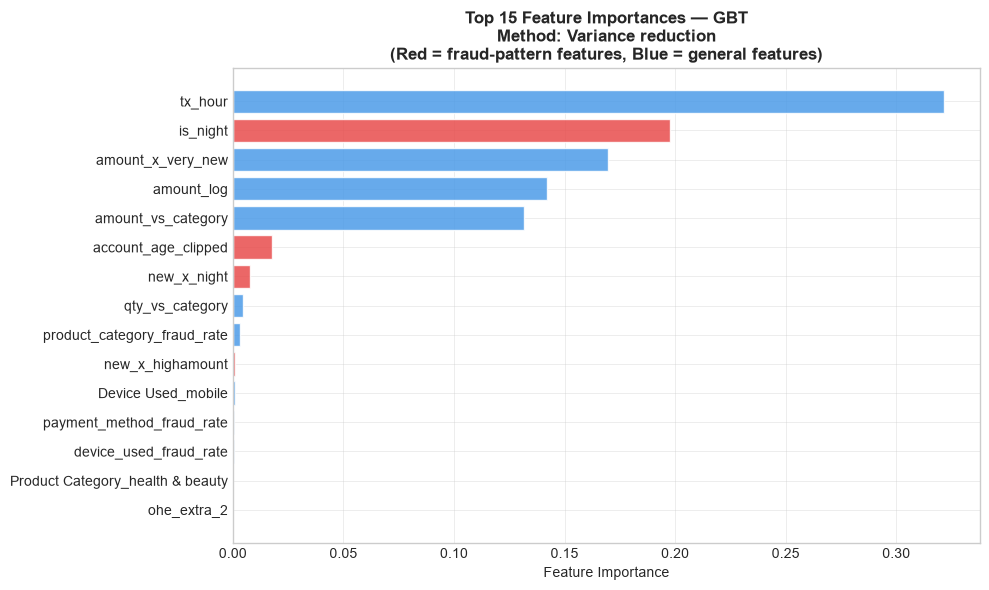

In [7]:
ohe_names = []
for col_base in SPARK_CAT:

    cats = sorted(X_train[col_base].dropna().unique())

    ohe_names += [f"{col_base}_{c}" for c in cats[:-1]]

all_feature_names = SPARK_NUM + SPARK_BIN + ohe_names

print(f"all_features  : {len(all_feature_names)}")
print(f"importances   : {len(importances_array)}")

if len(all_feature_names) != len(importances_array):
    print(f"⚠️  Lệch {len(importances_array) - len(all_feature_names)} — dùng generic names cho phần dư")
    extra = len(importances_array) - len(all_feature_names)
    all_feature_names += [f"ohe_extra_{i}" for i in range(extra)]


imp_df = pd.DataFrame({
    "Feature"   : all_feature_names[:len(importances_array)],
    "Importance": importances_array
}).sort_values("Importance", ascending=False).reset_index(drop=True)
imp_df.index += 1

print(f"\n Top 15 Feature Importances — {best_model_name}")
print(f"   Method: {method_note}")
# Hiển thị bảng feature importance. Không dùng .style để tránh lỗi thiếu jinja2 trên máy local.
display(imp_df.head(15).round(4))

plt.figure(figsize=(10, 6))
top15  = imp_df.head(15)
colors = ["#E84C4C" if f in ["new_night_highamount", "is_very_new_account",
                               "new_x_highamount", "is_night", "new_x_night",
                               "account_age_clipped"]
          else "#4C9BE8" for f in top15["Feature"]]
plt.barh(top15["Feature"][::-1], top15["Importance"][::-1],
         color=colors[::-1], alpha=0.85, edgecolor="white")
plt.xlabel(imp_label)
plt.title(f"Top 15 Feature Importances — {best_model_name}\n"
          f"Method: {method_note}\n"
          "(Red = fraud-pattern features, Blue = general features)",
          fontweight="bold")
plt.tight_layout()
plt.show()

##  Threshold Tuning (F2-optimized)


 Best threshold : 0.70  |  F2 = 0.5372


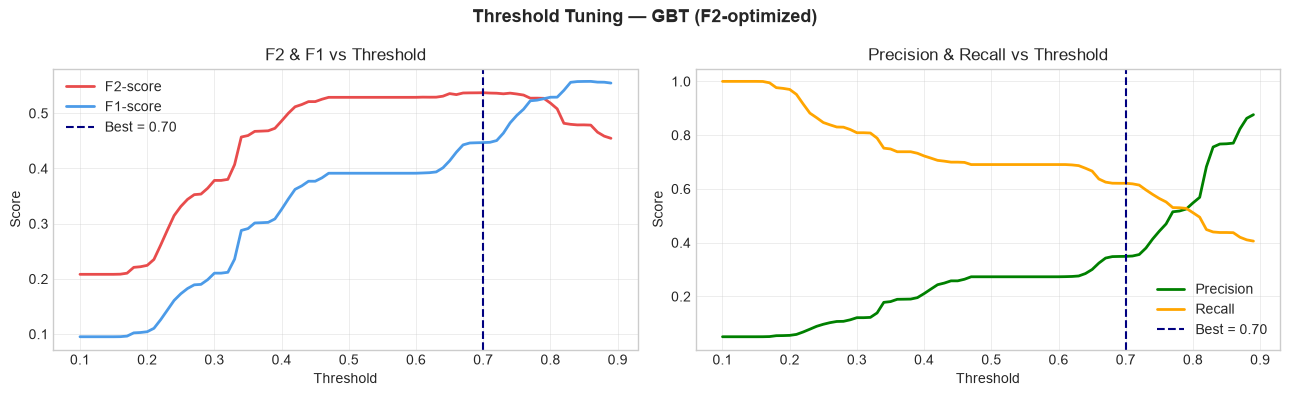

In [8]:
thresholds = np.arange(0.10, 0.90, 0.01)
thr_results = []
best_t, best_f2 = best_threshold, 0


for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f2   = fbeta_score(y_eval, y_pred, beta=2, zero_division=0)
    f1   = f1_score(y_eval, y_pred, zero_division=0)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec  = recall_score(y_eval, y_pred, zero_division=0)

    thr_results.append({"threshold": t, "f2": f2, "f1": f1,
                        "precision": prec, "recall": rec})
    if f2 > best_f2:
        best_f2, best_t = f2, t

thr_df = pd.DataFrame(thr_results)
print(f" Best threshold : {best_t:.2f}  |  F2 = {best_f2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Threshold Tuning — {best_model_name} (F2-optimized)",
             fontsize=13, fontweight="bold")

axes[0].plot(thr_df["threshold"], thr_df["f2"],
             color="#E84C4C", linewidth=2, label="F2-score")
axes[0].plot(thr_df["threshold"], thr_df["f1"],
             color="#4C9BE8", linewidth=2, label="F1-score")
axes[0].axvline(best_t, color="navy", linestyle="--",
                label=f"Best = {best_t:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("F2 & F1 vs Threshold")
axes[0].legend()

axes[1].plot(thr_df["threshold"], thr_df["precision"],
             color="green", linewidth=2, label="Precision")
axes[1].plot(thr_df["threshold"], thr_df["recall"],
             color="orange", linewidth=2, label="Recall")
axes[1].axvline(best_t, color="navy", linestyle="--",
                label=f"Best = {best_t:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision & Recall vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.show()


##  Đánh giá Final Model

### Metrics báo cáo
| Metric | Ý nghĩa |
|--------|---------|
| **F2-score** | Metric chính — penalize bỏ sót fraud |
| PR-AUC | Tổng thể, không bị ảnh hưởng imbalance |
| Recall | % fraud thực sự bị phát hiện |
| Confusion Matrix | TP / FP / TN / FN trực quan |

   FINAL MODEL: GBT  (threshold = 0.70)
   F2-score  : 0.5372   ← metric chính
  PR-AUC      : 0.5800   ← tổng thể
  ROC-AUC     : 0.8459
  F1-score    : 0.4468
  Recall      : 0.6209   ← 62.1% fraud phát hiện
  Precision   : 0.3490

  Confusion Matrix:
               Pred 0     Pred 1
  Actual 0    53,528     3,473  (TN / FP)
  Actual 1     1,137     1,862  (FN / TP)

  Fraud caught : 1,862 / 2,999  (62.1%)
  False alarms : 3,473 / 57,001  (6.1%)

              precision    recall  f1-score   support

   Non-Fraud       0.98      0.94      0.96     57001
       Fraud       0.35      0.62      0.45      2999

    accuracy                           0.92     60000
   macro avg       0.66      0.78      0.70     60000
weighted avg       0.95      0.92      0.93     60000



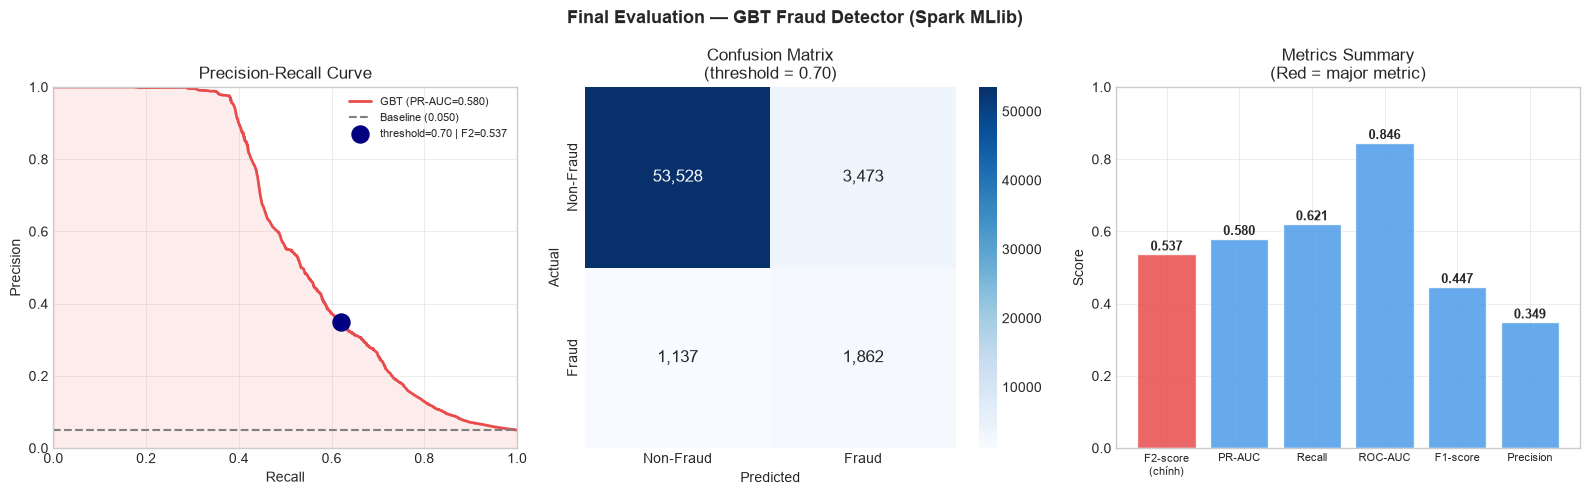

In [9]:
y_pred_final   = (y_prob >= best_t).astype(int)
cm             = confusion_matrix(y_eval, y_pred_final)
tn, fp, fn, tp = cm.ravel()

pr_auc    = average_precision_score(y_eval, y_prob)
roc_auc   = roc_auc_score(y_eval, y_prob)
f2_final  = fbeta_score(y_eval, y_pred_final, beta=2)
f1_final  = f1_score(y_eval, y_pred_final)
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print("=" * 60)
print(f"   FINAL MODEL: {best_model_name}  (threshold = {best_t:.2f})")
print("=" * 60)
print(f"   F2-score  : {f2_final:.4f}   ← metric chính")
print(f"  PR-AUC      : {pr_auc:.4f}   ← tổng thể")
print(f"  ROC-AUC     : {roc_auc:.4f}")
print(f"  F1-score    : {f1_final:.4f}")
print(f"  Recall      : {recall:.4f}   ← {recall*100:.1f}% fraud phát hiện")
print(f"  Precision   : {precision:.4f}")
print(f"\n  Confusion Matrix:")
print(f"               Pred 0     Pred 1")
print(f"  Actual 0  {tn:>8,}  {fp:>8,}  (TN / FP)")
print(f"  Actual 1  {fn:>8,}  {tp:>8,}  (FN / TP)")
print(f"\n  Fraud caught : {tp:,} / {tp+fn:,}  ({tp/(tp+fn)*100:.1f}%)")
print(f"  False alarms : {fp:,} / {tn+fp:,}  ({fp/(tn+fp)*100:.1f}%)")
print(f"\n{classification_report(y_eval, y_pred_final, target_names=['Non-Fraud','Fraud'])}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Final Evaluation — {best_model_name} Fraud Detector (Spark MLlib)",
             fontsize=13, fontweight="bold")

# 1. PR Curve
p_arr, r_arr, _ = precision_recall_curve(y_eval, y_prob)
axes[0].fill_between(r_arr, p_arr, alpha=0.1, color="#E84C4C")
axes[0].plot(r_arr, p_arr, color="#E84C4C", linewidth=2,
             label=f"{best_model_name} (PR-AUC={pr_auc:.3f})")
axes[0].axhline(np.mean(y_eval), color="gray", linestyle="--",
                label=f"Baseline ({np.mean(y_eval):.3f})")
axes[0].scatter([recall], [precision], s=150, zorder=5, color="navy",
                label=f"threshold={best_t:.2f} | F2={f2_final:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend(fontsize=8)
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1])

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=axes[1],
            xticklabels=["Non-Fraud","Fraud"],
            yticklabels=["Non-Fraud","Fraud"],
            annot_kws={"size": 12})
axes[1].set_title(f"Confusion Matrix\n(threshold = {best_t:.2f})")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

# 3. Metrics summary
metrics = {
    "F2-score\n(chính)": f2_final,
    "PR-AUC": pr_auc, "Recall": recall,
    "ROC-AUC": roc_auc, "F1-score": f1_final,
    "Precision": precision,
}
colors_bar = ["#E84C4C" if k.startswith("F2") else "#4C9BE8" for k in metrics.keys()]
bars = axes[2].bar(metrics.keys(), metrics.values(),
                   color=colors_bar, alpha=0.85, edgecolor="white")
axes[2].set_ylim([0, 1])
axes[2].set_title("Metrics Summary\n(Red = major metric)")
axes[2].set_ylabel("Score")
for bar, val in zip(bars, metrics.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
axes[2].tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()


## Kết luận & Tóm tắt Pipeline


In [10]:
print("   FRAUD DETECTION PIPELINE — SUMMARY")

print("KEY DECISIONS:")
print("   Đọc dữ liệu từ HDFS bằng Spark, có multiLine=True để xử lý địa chỉ xuống dòng")
print("   DROP IP & Location — leakage (corr train=0.99 vs test=0.006)")
print("   weightCol cho cả 3 models (thay vì SMOTE)")
print("   Threshold tuning F2 (recall > precision)")
print("   Smoothed target encoding (smoothing=20)")
print("   Auto model selection: best F2 trong LR / RF / GBT")
print()
print("FRAUD PATTERNS TỪ EDA:")
print("  • Giờ 0–5 sáng          : ~10.4%  (2.1x lift)")
print("  • Account age ≤ 30 ngày : ~22.2%  (4.4x lift)")
print("  • Amount top 20%        : ~10.3%  (2.1x lift)")
print("  • Kết hợp cả 3          : ~58.2%  (11.6x lift) ← strongest")
print()
print(f"KẾT QUẢ CUỐI CÙNG ({best_model_name} — Spark MLlib):")
print(f"   F2-score  : {f2_final:.4f}  ← metric chính")
print(f"  PR-AUC      : {pr_auc:.4f}  "
      f"(lift {pr_auc/np.mean(y_eval):.1f}x so với random baseline)")
print(f"  ROC-AUC     : {roc_auc:.4f}")
print(f"  Recall      : {recall:.4f}  → phát hiện {recall*100:.1f}% fraud")
print(f"  Precision   : {precision:.4f}")
print(f"  Threshold   : {best_t:.2f}  (tuned, không dùng default 0.5)")
print(f"  Fraud caught: {tp:,} / {tp+fn:,} cases")


   FRAUD DETECTION PIPELINE — SUMMARY
KEY DECISIONS:
   Đọc dữ liệu từ HDFS bằng Spark, có multiLine=True để xử lý địa chỉ xuống dòng
   DROP IP & Location — leakage (corr train=0.99 vs test=0.006)
   weightCol cho cả 3 models (thay vì SMOTE)
   Threshold tuning F2 (recall > precision)
   Smoothed target encoding (smoothing=20)
   Auto model selection: best F2 trong LR / RF / GBT

FRAUD PATTERNS TỪ EDA:
  • Giờ 0–5 sáng          : ~10.4%  (2.1x lift)
  • Account age ≤ 30 ngày : ~22.2%  (4.4x lift)
  • Amount top 20%        : ~10.3%  (2.1x lift)
  • Kết hợp cả 3          : ~58.2%  (11.6x lift) ← strongest

KẾT QUẢ CUỐI CÙNG (GBT — Spark MLlib):
   F2-score  : 0.5372  ← metric chính
  PR-AUC      : 0.5800  (lift 11.6x so với random baseline)
  ROC-AUC     : 0.8459
  Recall      : 0.6209  → phát hiện 62.1% fraud
  Precision   : 0.3490
  Threshold   : 0.70  (tuned, không dùng default 0.5)
  Fraud caught: 1,862 / 2,999 cases
